# 👾 PixelCNN using Tensorflow distributions

In this notebook, we'll walk through the steps required to train your own PixelCNN on the fashion MNIST dataset using Tensorflow distributions

In [1]:
import os, sys, logging

# Force CPU-only (no GPU conflict with other training)
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
# Suppress non-critical TF warnings before import
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
logging.getLogger('tensorflow').setLevel(logging.ERROR)

# Add workspace root for notebooks.utils
if r'D:\GenAIWithLLM' not in sys.path:
    sys.path.append(r'D:\GenAIWithLLM')

print(f"Python: {sys.version}")

%load_ext autoreload
%autoreload 2
import numpy as np

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
print(f"TF version: {tf.__version__}")
from tensorflow.keras import datasets, layers, models, optimizers, callbacks
import tensorflow_probability as tfp
print(f"TFP version: {tfp.__version__}")

from notebooks.utils import display
print("All imports successful!")

Python: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]

TF version: 2.15.1
TFP version: 0.23.0
All imports successful!


## 0. Parameters <a name="parameters"></a>

In [2]:
IMAGE_SIZE = 32
N_COMPONENTS = 5
EPOCHS = 10
BATCH_SIZE = 128

## 1. Prepare the data <a name="prepare"></a>

In [3]:
# Load the data
(x_train, _), (_, _) = datasets.fashion_mnist.load_data()

In [4]:
# Preprocess the data


def preprocess(imgs):
    imgs = np.expand_dims(imgs, -1)
    imgs = tf.image.resize(imgs, (IMAGE_SIZE, IMAGE_SIZE)).numpy()
    return imgs


input_data = preprocess(x_train)

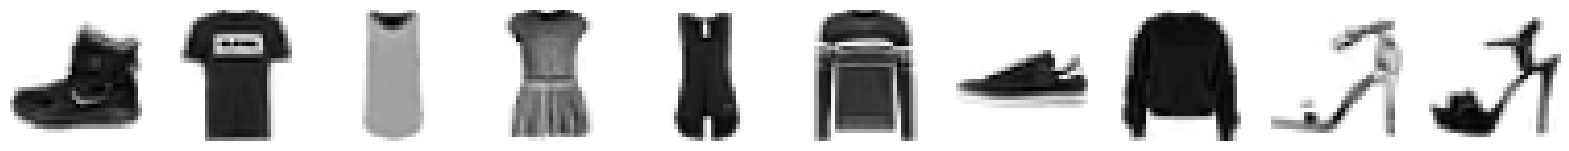

In [5]:
# Show some items of clothing from the training set
display(input_data)

## 2. Build the PixelCNN <a name="build"></a>

In [6]:
# Define a Pixel CNN network
dist = tfp.distributions.PixelCNN(
    image_shape=(IMAGE_SIZE, IMAGE_SIZE, 1),
    num_resnet=1,
    num_hierarchies=2,
    num_filters=32,
    num_logistic_mix=N_COMPONENTS,
    dropout_p=0.3,
)

# Define the model input
image_input = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 1))

# Define the log likelihood for the loss fn
log_prob = dist.log_prob(image_input)

# Define the model
pixelcnn = models.Model(inputs=image_input, outputs=log_prob)
pixelcnn.add_loss(-tf.reduce_mean(log_prob))

## 3. Train the PixelCNN <a name="train"></a>

In [7]:
# Compile and train the model
pixelcnn.compile(
    optimizer=optimizers.Adam(0.001),
)

In [8]:
tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")


class ImageGenerator(callbacks.Callback):
    def __init__(self, num_img):
        self.num_img = num_img

    def generate(self):
        return dist.sample(self.num_img).numpy()

    def on_epoch_end(self, epoch, logs=None):
        generated_images = self.generate()
        display(
            generated_images,
            n=self.num_img,
            save_to="./output/generated_img_%03d.png" % (epoch),
        )


img_generator_callback = ImageGenerator(num_img=2)

Epoch 1/10
469/469 [==============================] - ETA: 0s - loss: 2337.0098
Saved to ./output/generated_img_000.png


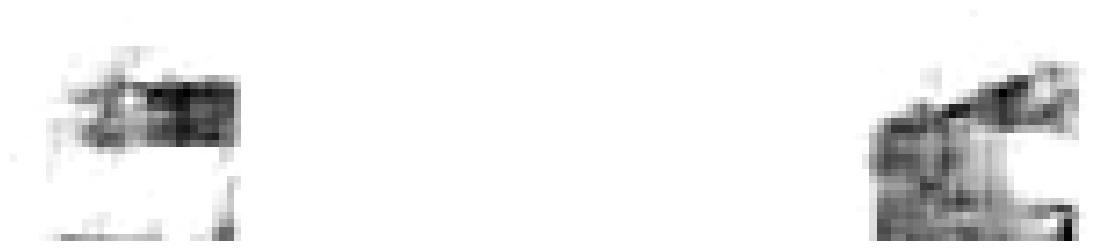

469/469 [==============================] - 409s 852ms/step - loss: 2337.0098
Epoch 2/10
469/469 [==============================] - ETA: 0s - loss: 2055.0151
Saved to ./output/generated_img_001.png


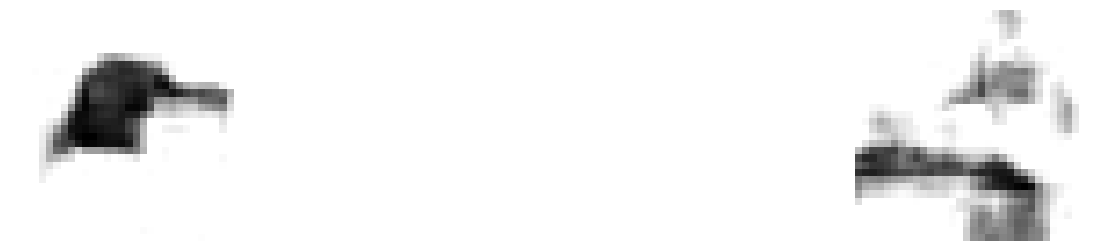

469/469 [==============================] - 425s 907ms/step - loss: 2055.0151
Epoch 3/10
469/469 [==============================] - ETA: 0s - loss: 1973.4811
Saved to ./output/generated_img_002.png


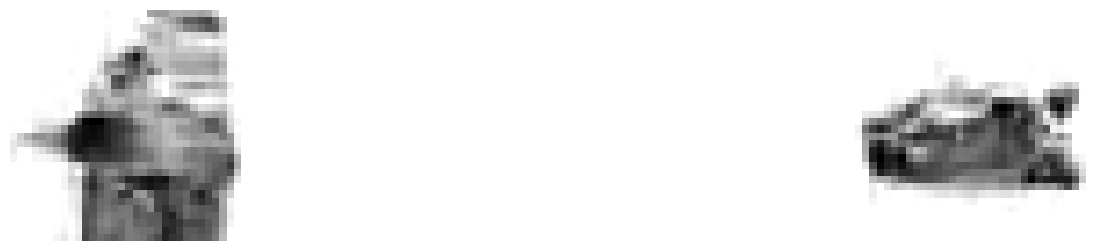

469/469 [==============================] - 414s 883ms/step - loss: 1973.4811
Epoch 4/10
469/469 [==============================] - ETA: 0s - loss: 1921.6002
Saved to ./output/generated_img_003.png


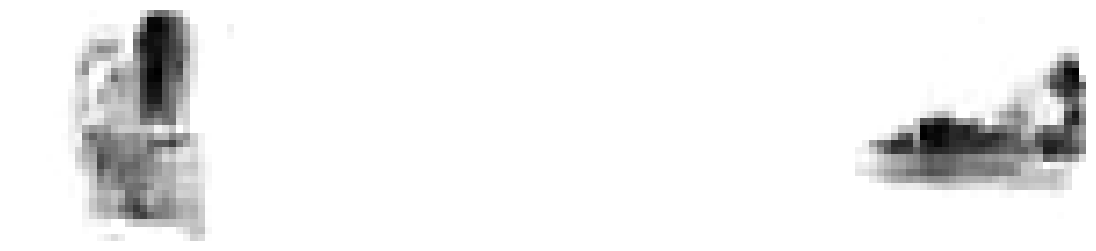

469/469 [==============================] - 418s 892ms/step - loss: 1921.6002
Epoch 5/10
469/469 [==============================] - ETA: 0s - loss: 1885.7704
Saved to ./output/generated_img_004.png


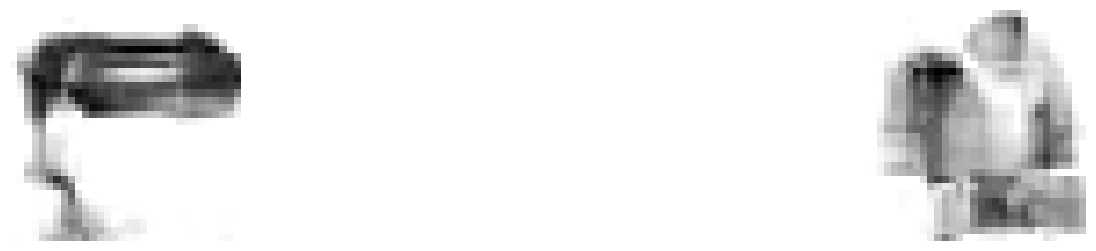

469/469 [==============================] - 414s 884ms/step - loss: 1885.7704
Epoch 6/10
469/469 [==============================] - ETA: 0s - loss: 1856.5326
Saved to ./output/generated_img_005.png


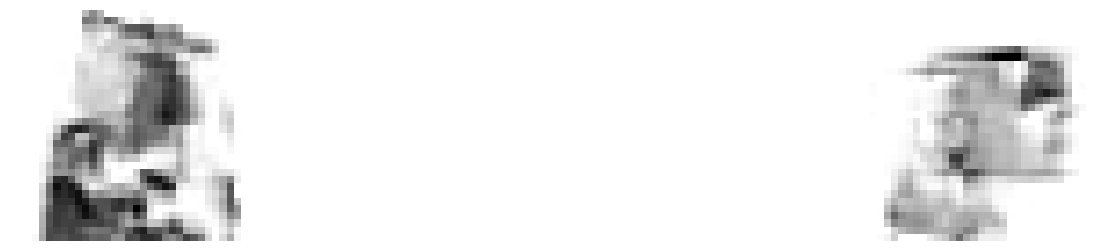

469/469 [==============================] - 410s 874ms/step - loss: 1856.5326
Epoch 7/10
469/469 [==============================] - ETA: 0s - loss: 1835.2756
Saved to ./output/generated_img_006.png


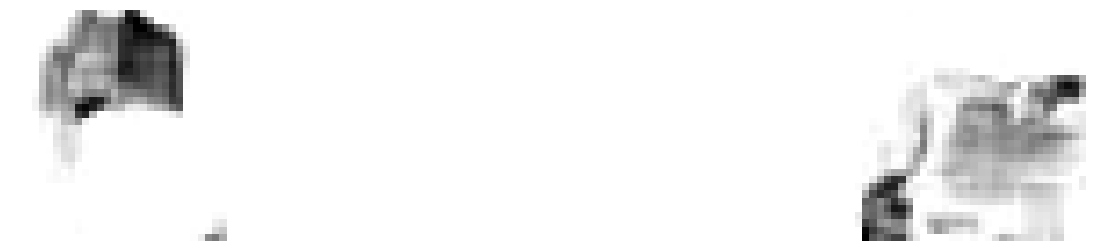

469/469 [==============================] - 412s 879ms/step - loss: 1835.2756
Epoch 8/10
469/469 [==============================] - ETA: 0s - loss: 1820.6356
Saved to ./output/generated_img_007.png


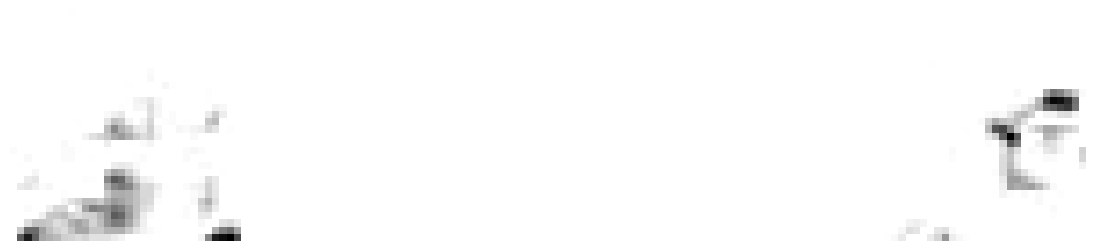

469/469 [==============================] - 411s 877ms/step - loss: 1820.6356
Epoch 9/10
469/469 [==============================] - ETA: 0s - loss: 1800.0461
Saved to ./output/generated_img_008.png


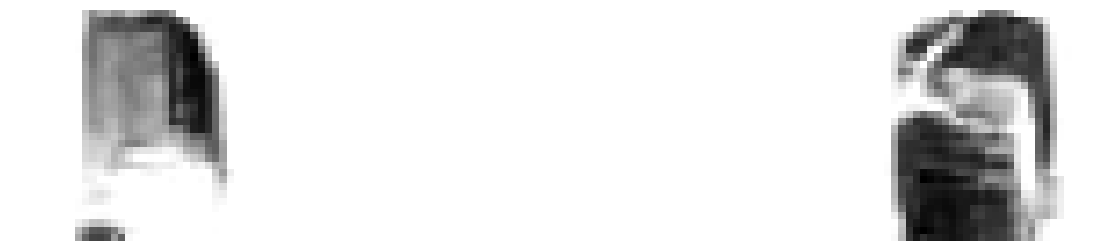

469/469 [==============================] - 406s 866ms/step - loss: 1800.0461
Epoch 10/10
469/469 [==============================] - ETA: 0s - loss: 1789.3530
Saved to ./output/generated_img_009.png


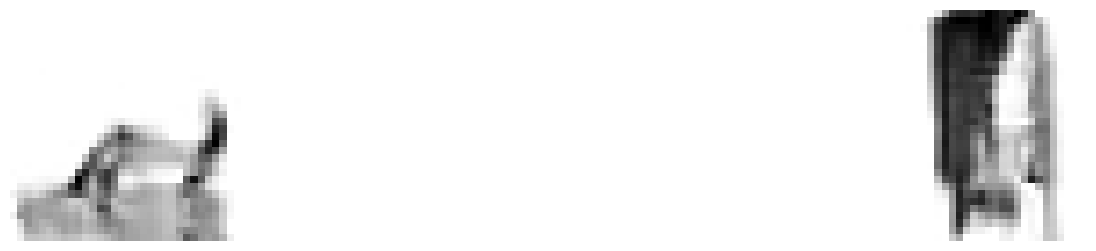

469/469 [==============================] - 414s 882ms/step - loss: 1789.3530


In [9]:
pixelcnn.fit(
    input_data,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=True,
    callbacks=[tensorboard_callback, img_generator_callback],
)

## 4. Generate images <a name="generate"></a>

In [10]:
generated_images = img_generator_callback.generate()

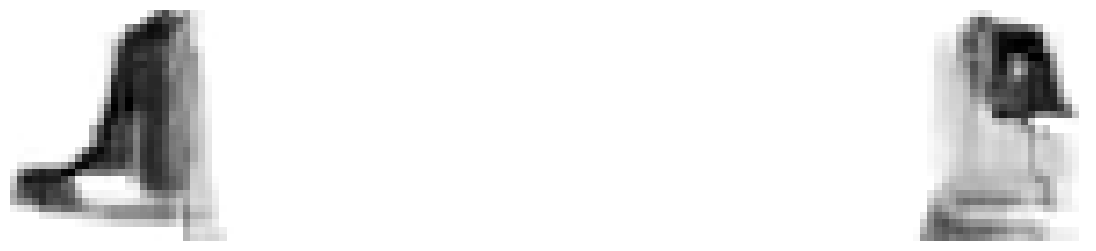

In [11]:
display(generated_images, n=img_generator_callback.num_img)

## 5. Observations and Analysis

The model was trained for 10 epochs on Fashion MNIST using the TensorFlow Probability PixelCNN distribution. The training loss dropped from 2337 down to 1789, showing the model steadily learned the pixel level patterns in the data. Early epochs saw the biggest jumps in improvement while later epochs showed smaller but still consistent gains.

Looking at the generated images across epochs, the first few rounds produced mostly noisy output with faint shapes. Around the midway point recognizable clothing items like shoes and shirts started to take form. By the final epoch the samples clearly resemble Fashion MNIST items with proper structure and shading, though they are not perfectly crisp given the limited training.

The PixelCNN works by modeling each pixel as a conditional distribution based on all previously seen pixels, scanning left to right and top to bottom (Foster, 2022). The output uses a mixture of 5 logistic distributions per pixel which gives the model flexibility to handle different intensity patterns without needing a full 256 way categorical output. New images are generated by calling dist.sample() which draws from these learned distributions one pixel at a time.

Overall the model successfully learned to generate Fashion MNIST style images from scratch using an autoregressive approach. Longer training or a deeper architecture would improve sharpness but the current results demonstrate the core idea well.

---

**AI Usage Note:** This assignment used GitHub Copilot to assist with summarizing the training observations. All model training and results were produced independently.

**Reference:** Foster, D. (2022). *Generative Deep Learning* (2nd ed.). O'Reilly Media, Inc.